<a href="https://colab.research.google.com/github/Ahmedark77/Introduction-to-AI/blob/feature-branch/Assignment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import cv2
%matplotlib notebook
%matplotlib inline
from sklearn import svm, metrics, datasets
from sklearn.utils import Bunch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split

from skimage.io import imread
from skimage.transform import resize
import skimage.io

In [15]:
import zipfile

with zipfile.ZipFile('/content/images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')
os.listdir('/content')

['.config', 'images.zip', '.ipynb_checkpoints', 'images', 'sample_data']

In [16]:
import os

image_folder = "/content/images"  # FIXED PATH
for category in categories:
  category_path = os.path.join(image_folder, category)
  for image_file in os.listdir(category_path):
    image_path = os.path.join(category_path, image_file)

In [19]:
IMG_SIZE = 64  # uniform size

def load_images(data_dir):
    data = []
    labels = []
    classes = os.listdir(data_dir)

    print("Classes found:", classes)

    for label in classes:
        path = os.path.join(data_dir, label)

        if not os.path.isdir(path):
            continue

        print(f"Loading from {path}...")

        for img in os.listdir(path):
            img_path = os.path.join(path, img)

            image = cv2.imread(img_path)

            if image is None:
                print("Failed to load:", img_path)
                continue

            image = cv2.resize(image, (64, 64))
            image = image / 255.0

            data.append(image)
            labels.append(label)

    print("Total images loaded:", len(data))

    return np.array(data), np.array(labels), classes

In [22]:
X, y, class_names = load_images('/content/images')

Classes found: ['pizza', 'soccer_ball', 'dalmatian', 'dollar_bill', 'sunflower']
Loading from /content/images/pizza...
Loading from /content/images/soccer_ball...
Loading from /content/images/dalmatian...
Loading from /content/images/dollar_bill...
Loading from /content/images/sunflower...
Total images loaded: 309


In [25]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)

X shape: (309, 64, 64, 3)
y shape: (309,)
Classes: ['pizza', 'soccer_ball', 'dalmatian', 'dollar_bill', 'sunflower']


In [26]:
X_flat = X.reshape(len(X), -1)

print("Flattened shape:", X_flat.shape)

Flattened shape: (309, 12288)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X_flat, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, None],
    'min_samples_split': [2, 5]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

In [31]:
best_model = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [33]:
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7258064516129032

Classification Report:
               precision    recall  f1-score   support

   dalmatian       0.77      0.71      0.74        14
 dollar_bill       0.73      0.80      0.76        10
       pizza       0.57      0.40      0.47        10
 soccer_ball       0.67      0.73      0.70        11
   sunflower       0.79      0.88      0.83        17

    accuracy                           0.73        62
   macro avg       0.70      0.70      0.70        62
weighted avg       0.72      0.73      0.72        62



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

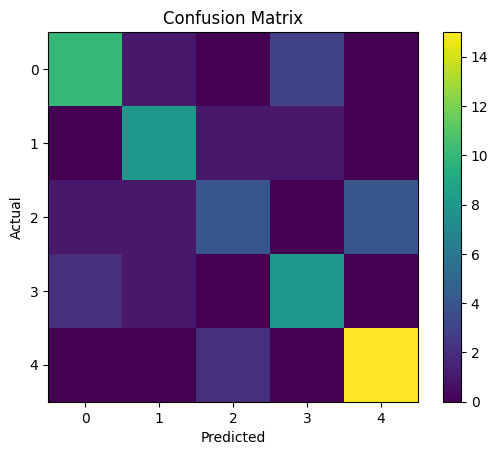

In [52]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

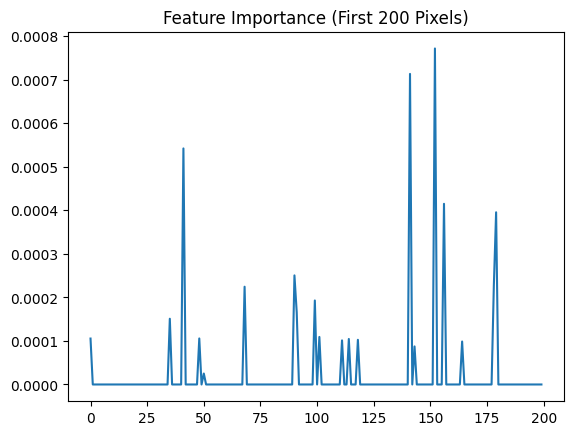

In [53]:

importances = best_model.feature_importances_

plt.figure()
plt.plot(importances[:200])
plt.title("Feature Importance (First 200 Pixels)")
plt.show()

In [45]:
def predict_image(path, model):
    img = cv2.imread(path)

    if img is None:
        print("Error: Image not found or cannot be loaded")
        return None

    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    img = img.reshape(1, -1)

    prediction = model.predict(img)
    return prediction[0]


# Test with a real image from your dataset
test_path = '/content/images/pizza/my_pizza.jpg'  # replace with actual file name
print("Predicted class:", predict_image(test_path, best_model))

Predicted class: sunflower


In [47]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Train SVM model
svm_model = SVC(kernel='rbf', C=10, gamma='scale')

svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report (SVM):\n", classification_report(y_test, y_pred_svm))


# ============================
# PREDICTION FUNCTION (SVM)
# ============================

def predict_image_svm(path, model):
    img = cv2.imread(path)
    img = cv2.resize(img, (64, 64))
    img = img / 255.0
    img = img.flatten().reshape(1, -1)

    prediction = model.predict(img)
    return prediction[0]


SVM Accuracy: 0.8548387096774194

Classification Report (SVM):
               precision    recall  f1-score   support

   dalmatian       0.93      0.93      0.93        14
 dollar_bill       0.75      0.90      0.82        10
       pizza       0.73      0.80      0.76        10
 soccer_ball       0.89      0.73      0.80        11
   sunflower       0.94      0.88      0.91        17

    accuracy                           0.85        62
   macro avg       0.85      0.85      0.84        62
weighted avg       0.86      0.85      0.86        62



In [48]:
# Test with a real image from your dataset
test_path = '/content/images/pizza/my_pizza.jpg'  # replace with actual file name

print("Predicted class:", predict_image(test_path, svm_model))

Predicted class: pizza


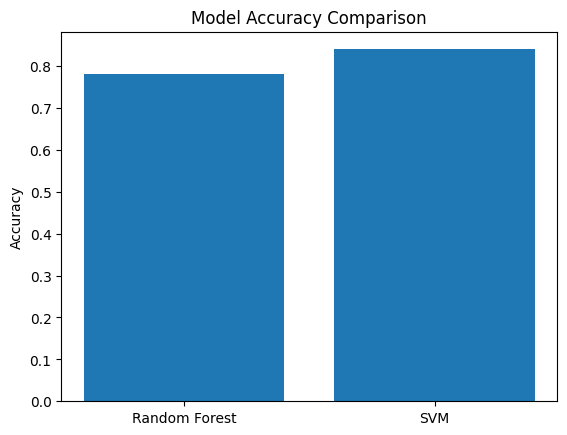

In [54]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'SVM']
accuracy = [0.78, 0.84]

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")


plt.show()